### **Image Classification using Transfer Learning(MobileNetV2)**
- Prepared By: **Aayush Khatiwada**  
- L6CG13 | Student ID: 2407726

In this notebook, I have fine-tuned MobileNetV2 model to classify the diseased plants.

# **Import Libraries**

In [ ]:
import os, kagglehub, shutil, random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from keras import layers
from keras.models import Sequential
from keras.layers import GlobalAveragePooling2D, BatchNormalization, Dense, Dropout, Rescaling
from keras.applications import MobileNetV2
from keras.optimizers import Adam
from keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

#**Dataset Curation**

In [ ]:
# Extract dataset from kaggle to colab
src = kagglehub.dataset_download("abdallahalidev/plantvillage-dataset")

Using Colab cache for faster access to the 'plantvillage-dataset' dataset.


In [ ]:
# Move the dataset to /content for faster access
dst = '/content/plant'
if not os.path.exists(dst):
    shutil.copytree(Path(src, 'plantvillage dataset/color'), dst)
else:
    print("Destination already exists. Skipping copy.")

In [ ]:
# Check dataset structure
classes = os.listdir(dst)
print("Total classes:", len(classes))
print(classes[:10])

Total classes: 38
['Apple___healthy', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Potato___Late_blight', 'Tomato___Target_Spot', 'Grape___Black_rot', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Tomato___Leaf_Mold', 'Tomato___Bacterial_spot', 'Pepper,_bell___healthy']


In [ ]:
# Set paths for train, validation and test sets
train_dir = Path("/content/data/train")
val_dir   = Path("/content/data/val")
test_dir  = Path("/content/data/test")

for d in [train_dir, val_dir, test_dir]:
    d.mkdir(parents=True, exist_ok=True)

In [ ]:
# Function to split data into train, test and validation sets randomly
def split_data(src_dir, train_dir, val_dir, test_dir, split=(0.7, 0.15, 0.15)):
    for cls in os.listdir(src_dir):
        images = os.listdir(os.path.join(src_dir, cls))
        random.shuffle(images)

        n = len(images)
        train_split = int(split[0] * n)
        val_split   = int(split[1] * n)

        train_imgs = images[:train_split]
        val_imgs   = images[train_split:train_split+val_split]
        test_imgs  = images[train_split+val_split:]

        for folder, img_list in zip(
            [train_dir, val_dir, test_dir],
            [train_imgs, val_imgs, test_imgs]
        ):
            cls_path = folder / cls
            cls_path.mkdir(parents=True, exist_ok=True)

            for img in img_list:
                src = os.path.join(src_dir, cls, img)
                dst = cls_path / img
                shutil.copy(src, dst)

In [ ]:
# Call split function
split_data('/content/plant', train_dir, val_dir, test_dir)

In [ ]:
# Count the number of images per split
def count_images(directory):
    counts = {}
    for cls in os.listdir(directory):
        counts[cls] = len(os.listdir(os.path.join(directory, cls)))
    return counts

print("Train:", count_images(train_dir))
print("Val:", count_images(val_dir))
print("Test:", count_images(test_dir))

Train: {'Apple___healthy': 1151, 'Tomato___Spider_mites Two-spotted_spider_mite': 1173, 'Tomato___Tomato_Yellow_Leaf_Curl_Virus': 3749, 'Potato___Late_blight': 700, 'Tomato___Target_Spot': 982, 'Grape___Black_rot': 826, 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 359, 'Tomato___Leaf_Mold': 666, 'Tomato___Bacterial_spot': 1488, 'Pepper,_bell___healthy': 1034, 'Tomato___healthy': 1113, 'Blueberry___healthy': 1051, 'Peach___Bacterial_spot': 1607, 'Apple___Black_rot': 434, 'Corn_(maize)___healthy': 813, 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 753, 'Strawberry___Leaf_scorch': 776, 'Potato___healthy': 106, 'Apple___Apple_scab': 441, 'Grape___healthy': 296, 'Cherry_(including_sour)___Powdery_mildew': 736, 'Peach___healthy': 251, 'Potato___Early_blight': 700, 'Cherry_(including_sour)___healthy': 597, 'Pepper,_bell___Bacterial_spot': 697, 'Soybean___healthy': 3563, 'Tomato___Tomato_mosaic_virus': 261, 'Strawberry___healthy': 319, 'Apple___Cedar_apple_rust': 192, 'Raspberry___hea

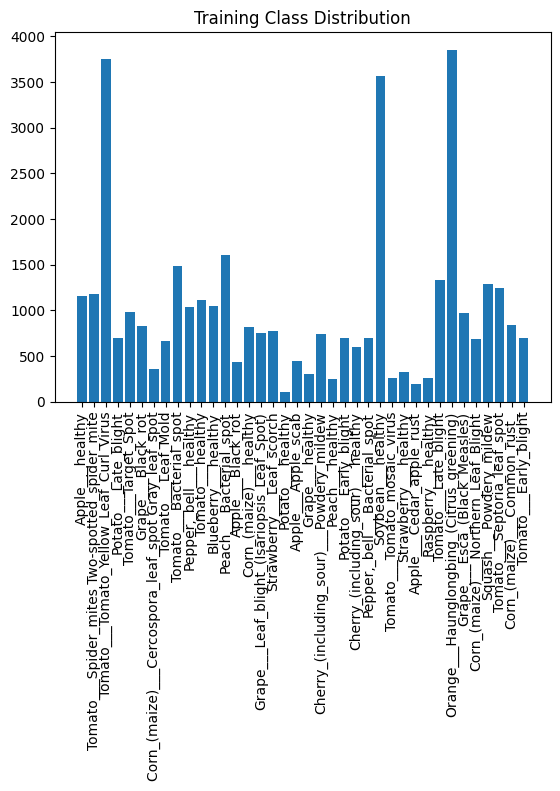

In [ ]:
# Visualize class distribution
counts = count_images(train_dir)

plt.bar(counts.keys(), counts.values())
plt.xticks(rotation=90)
plt.title("Training Class Distribution")
plt.show()

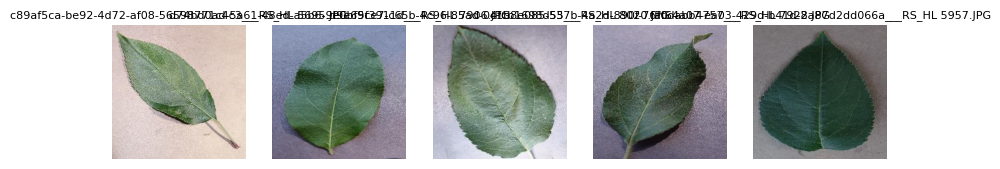

In [ ]:
# Visualize some images
sample_class = list(counts.keys())[0]
sample_images = os.listdir(train_dir / sample_class)[:5]

plt.figure(figsize=(10,5))

for i, img_name in enumerate(sample_images):
    img = Image.open(train_dir / sample_class / img_name)
    plt.subplot(1,5,i+1)
    plt.title(img_name, fontsize=8)
    plt.imshow(img)
    plt.axis('off')

plt.show()

# **Data Pipeline**

In [ ]:
# Load data using tensorflow

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/data/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/data/val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/data/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 37997 files belonging to 38 classes.
Found 8129 files belonging to 38 classes.
Found 8179 files belonging to 38 classes.


In [ ]:
# Extract class names

class_names = train_ds.class_names
num_classes = len(class_names)

print(num_classes)
print(class_names[:5])

38
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']


In [ ]:
# Normalize the data
normalization_layer = Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds   = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds  = test_ds.map(lambda x, y: (normalization_layer(x), y))

## Data Agumentation

In [ ]:
# Define steps to be used to Augment data

data_augmentation = Sequential([
    tf.keras.Input(shape=(224, 224, 3)),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.1),
])

In [ ]:
# Augment only the train set

def augment(x, y):
    return data_augmentation(x, training=True), y

train_ds = train_ds.map(augment)

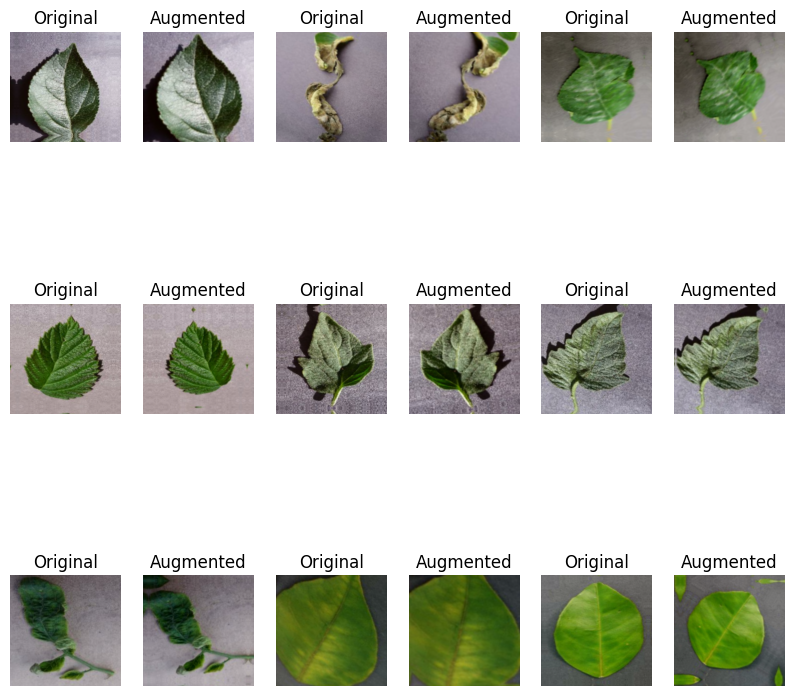

In [ ]:
# Visualize agumented Data
for images, labels in train_ds.take(1):
    plt.figure(figsize=(10, 10))

    for i in range(9):
        # original
        ax = plt.subplot(3, 6, 2*i + 1)
        plt.imshow(images[i].numpy())
        plt.title("Original")
        plt.axis("off")

        # augmented
        augmented = data_augmentation(images[i:i+1])[0]
        ax = plt.subplot(3, 6, 2*i + 2)
        plt.imshow(augmented.numpy())
        plt.title("Augmented")
        plt.axis("off")

plt.show()

In [ ]:
# Check image shape to ensure correct image loading + normalization

for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)


# **Base Model**

In [ ]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

In [ ]:
# Compute weights to be assigned to each class
y_train = []

for images, labels in train_ds:
    y_train.extend(labels.numpy())

y_train = np.array(y_train)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(2.267394677169113), 1: np.float64(2.3039655590589376), 2: np.float64(5.207922149122807), 3: np.float64(0.8687411404270886), 4: np.float64(0.9513996694877059), 5: np.float64(1.358588386727689), 6: np.float64(1.6749096358987923), 7: np.float64(2.7852954112300248), 8: np.float64(1.1989461062728763), 9: np.float64(1.4512642273317546), 10: np.float64(1.229915193888781), 11: np.float64(1.210558175098764), 12: np.float64(1.0329762940408873), 13: np.float64(1.3279164045572098), 14: np.float64(3.378111664295875), 15: np.float64(0.2594501952858274), 16: np.float64(0.6222284086070808), 17: np.float64(3.9837492136716293), 18: np.float64(1.434606962168693), 19: np.float64(0.9670416369744477), 20: np.float64(1.4284586466165414), 21: np.float64(1.4284586466165414), 22: np.float64(9.433217477656406), 23: np.float64(3.860699044909571), 24: np.float64(0.2806402056221103), 25: np.float64(0.7787547138875226), 26: np.float64(1.2885580575149214), 27: np.float64(3.1345487543309685), 28: np.flo

#**Feature Extraction Phase**

##**Freeze Base Model**

In [ ]:
base_model.trainable = False

##**Build Final Model**

In [ ]:
model = Sequential([
    base_model,

    GlobalAveragePooling2D(),

    BatchNormalization(),
    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(num_classes, activation='softmax')
])

##**Compile**

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        patience=2,
        factor=0.3,
        verbose=1
    ),

    ModelCheckpoint(
    "best_model.keras",
    save_best_only=True
)
]

##**Train**

In [ ]:
start = time.time()
history_fe = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights,
    callbacks=callbacks
)
end = time.time()
time_taken = end - start
print(f'The training process ran for {time_taken:.2f} seconds')

Epoch 1/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 511s 421ms/step - accuracy: 0.7611 - loss: 0.8622 - val_accuracy: 0.9079 - val_loss: 0.2908 - learning_rate: 0.0010
Epoch 2/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 495s 417ms/step - accuracy: 0.8491 - loss: 0.5016 - val_accuracy: 0.9081 - val_loss: 0.2927 - learning_rate: 0.0010
Epoch 3/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 494s 416ms/step - accuracy: 0.8629 - loss: 0.4404 - val_accuracy: 0.9227 - val_loss: 0.2447 - learning_rate: 0.0010
Epoch 4/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 483s 406ms/step - accuracy: 0.8718 - loss: 0.4067 - val_accuracy: 0.9295 - val_loss: 0.2267 - learning_rate: 0.0010
Epoch 5/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 486s 409ms/step - accuracy: 0.8751 - loss: 0.3958 - val_accuracy: 0.9239 - val_loss: 0.2469 - learning_rate: 0.0010
Epoch 6/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step - accuracy: 0.8789 - loss: 0.3875
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 482s 406ms/st

#**Fine-Tuning Phase**

##**Unfreeze Last Layers**

In [ ]:
base_model.trainable = True

# Freeze early layers, unfreeze top layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

##**Recompile**

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

**Note:** Lower learning rate is used to prevent catastrophic forgetting in the model

##**Train**

In [ ]:
start = time.time()
history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights,
    callbacks=callbacks
)
end = time.time()
time_taken = end - start
print(f'Fine tuning process ran for {time_taken:.2f} seconds')

Epoch 1/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 527s 428ms/step - accuracy: 0.8327 - loss: 0.5445 - val_accuracy: 0.9170 - val_loss: 0.2946 - learning_rate: 1.0000e-05
Epoch 2/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step - accuracy: 0.8702 - loss: 0.3899
Epoch 2: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 499s 420ms/step - accuracy: 0.8742 - loss: 0.3784 - val_accuracy: 0.9315 - val_loss: 0.2192 - learning_rate: 1.0000e-05
Epoch 3/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 501s 421ms/step - accuracy: 0.8916 - loss: 0.3237 - val_accuracy: 0.9337 - val_loss: 0.2017 - learning_rate: 3.0000e-06
Fine tuning process ran for 1526.01 seconds


#**Save Final Model**

In [ ]:
model.save("final_model.keras")

#**Plot Comparison (Feature Extraction vs Fine-tuning)**

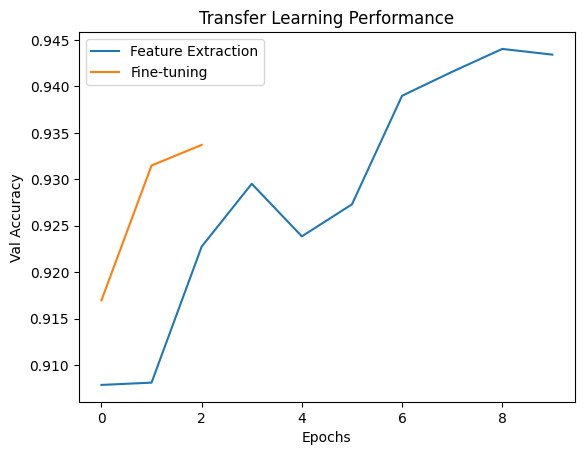

In [ ]:
plt.plot(history_fe.history['val_accuracy'], label='Feature Extraction')
plt.plot(history_ft.history['val_accuracy'], label='Fine-tuning')

plt.title("Transfer Learning Performance")
plt.xlabel("Epochs")
plt.ylabel("Val Accuracy")
plt.legend()
plt.show()

# **Evaluation**

In [ ]:
# Get predictions for test set

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━

In [ ]:
# Get metrics for evaluation of the model
print(classification_report(y_true, y_pred, target_names=class_names))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.85      0.93      0.89        95
                                 Apple___Black_rot       0.95      0.95      0.95        94
                          Apple___Cedar_apple_rust       0.98      0.98      0.98        42
                                   Apple___healthy       0.97      0.97      0.97       248
                               Blueberry___healthy       1.00      0.92      0.96       226
          Cherry_(including_sour)___Powdery_mildew       0.99      0.97      0.98       159
                 Cherry_(including_sour)___healthy       0.91      0.98      0.94       129
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.76      0.83      0.80        78
                       Corn_(maize)___Common_rust_       0.99      0.98      0.99       180
               Corn_(maize)___Northern_Leaf_Blight       0.90      0.87      0.

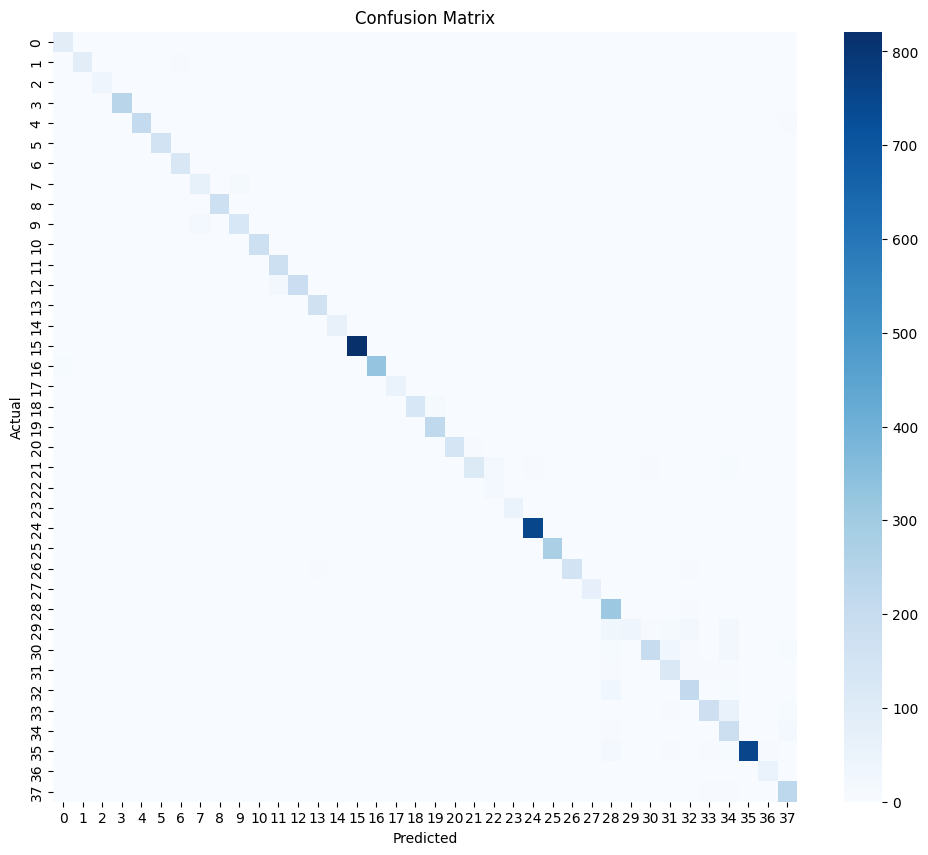

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=False, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()